# Imports

In [ ]:
import sys
from pathlib import Path

current_dir = Path.cwd()
if current_dir.name == "notebooks":
    ROOT = current_dir.parent
else:
    ROOT = current_dir

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Repo root:", ROOT)

Repo root: c:\Users\Navya\Desktop\Quant Projects\derivatives-risk-engine


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kurtosis

from src.gbm import GBMSimulator
from src.utils import get_hist_prices, annualize_vol

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Historical Data and Estimate Parameters

In [4]:
ticker = "SPY"
prices = get_hist_prices(ticker, period="5y")
returns = np.log(prices / prices.shift(1)).dropna()

S0 = float(prices.iloc[-1])
mu_hat = float(returns.mean() * 252)
sigma_hat = float(returns.std(ddof=1) * np.sqrt(252))

print(f"{ticker} S0:", S0)
print(f"{ticker} annualized drift estimate mu_hat:", mu_hat)
print(f"{ticker} annualized vol estimate sigma_hat:", sigma_hat)

SPY S0: 741.75
SPY annualized drift estimate mu_hat: 0.12541942379669208
SPY annualized vol estimate sigma_hat: 0.17096361855968664


Configure and GBM

In [5]:
T = 1.0
dt = 1 / 252
n_paths = 10000

sim = GBMSimulator(S0=S0, mu=mu_hat, sigma=sigma_hat, T=T, dt=dt, n_paths=n_paths)
paths = sim.simulate()
terminal = sim.terminal_distribution()

print("GBM paths shape:", paths.shape)
print("Terminal distribution shape:", terminal.shape)

GBM paths shape: (10000, 253)
Terminal distribution shape: (10000,)


# Plot GBM

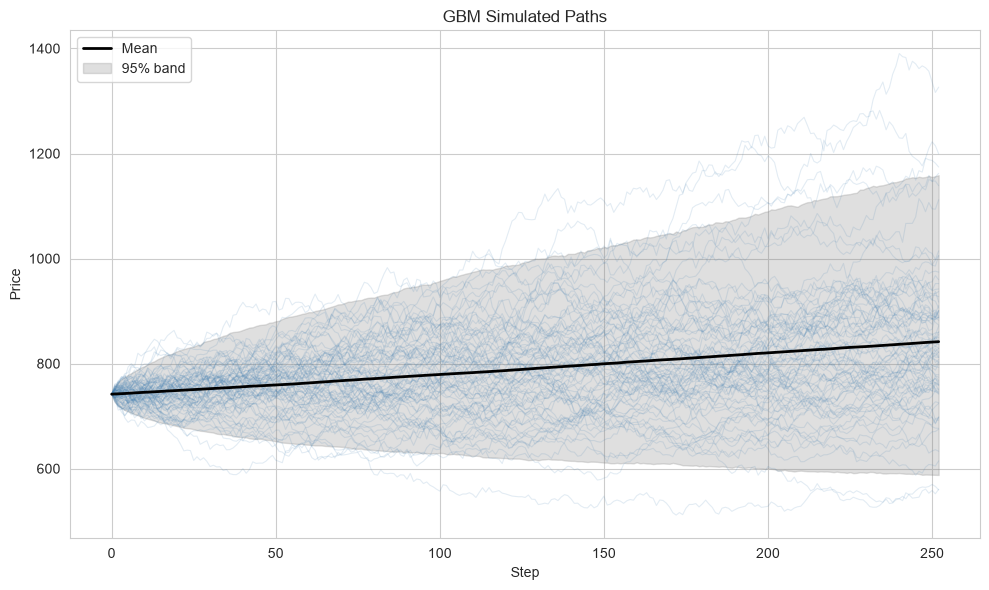

In [6]:
fig = sim.plot_paths(n_display=75, band=0.95)
plt.show()

# Terminal Price Dist vs Theoretical Lognormal Desnity

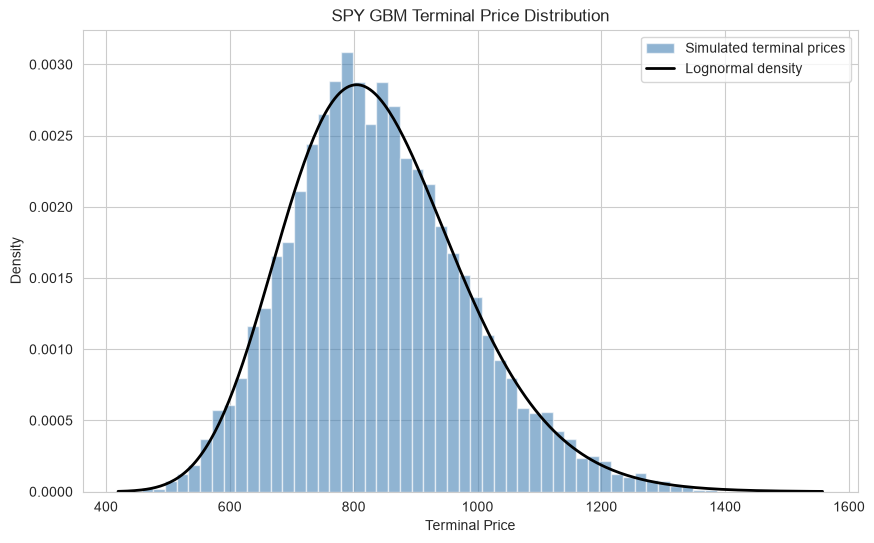

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(terminal, bins=60, density=True, alpha=0.6, color="steelblue", label="Simulated terminal prices")

x = np.linspace(terminal.min(), terminal.max(), 300)
mu_T = np.log(S0) + (mu_hat - 0.5 * sigma_hat**2) * T
sd_T = sigma_hat * np.sqrt(T)
pdf = (1 / (x * sd_T * np.sqrt(2 * np.pi))) * np.exp(-(np.log(x) - mu_T) ** 2 / (2 * sd_T**2))
ax.plot(x, pdf, color="black", lw=2, label="Lognormal density")

ax.set_title(f"{ticker} GBM Terminal Price Distribution")
ax.set_xlabel("Terminal Price")
ax.set_ylabel("Density")
ax.legend()
plt.show()

# Simulated vs Historical Returns and QQ Plot

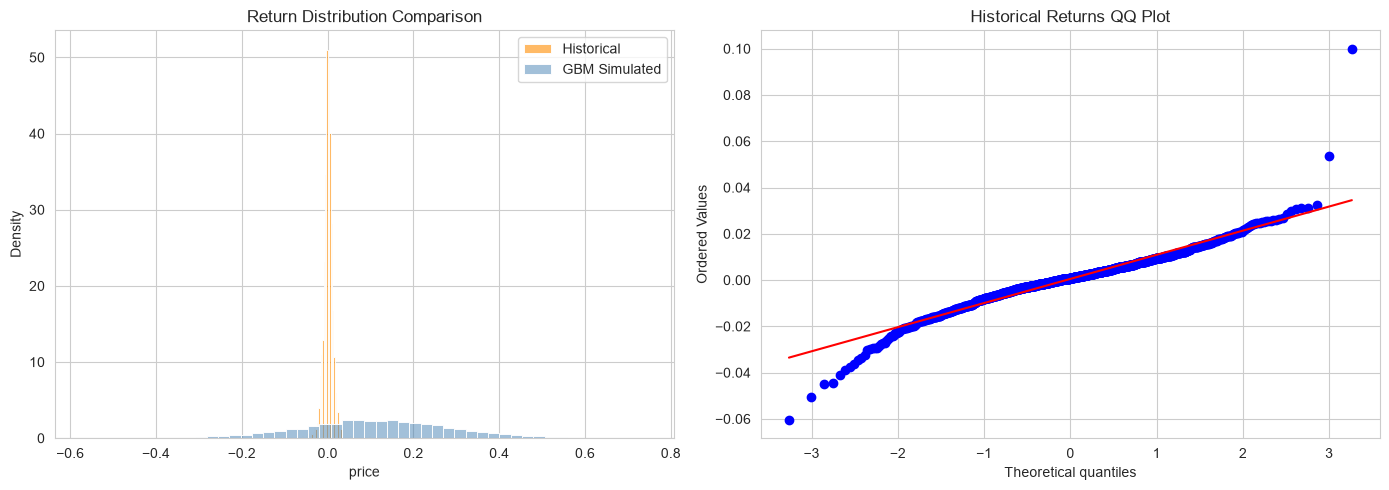

In [8]:
sim_returns = np.log(terminal / S0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(returns, bins=50, stat="density", color="darkorange", alpha=0.6, ax=axes[0], label="Historical")
sns.histplot(sim_returns, bins=50, stat="density", color="steelblue", alpha=0.5, ax=axes[0], label="GBM Simulated")
axes[0].set_title("Return Distribution Comparison")
axes[0].legend()

from scipy.stats import probplot
probplot(returns, dist="norm", plot=axes[1])
axes[1].set_title("Historical Returns QQ Plot")

plt.tight_layout()
plt.show()

# Kurtosis and Tail Discrepancy

In [9]:
hist_kurt = kurtosis(returns, fisher=False)
sim_kurt = kurtosis(sim_returns, fisher=False)

summary = pd.DataFrame({
    "series": ["historical_returns", "simulated_terminal_returns"],
    "kurtosis": [hist_kurt, sim_kurt],
    "mean": [returns.mean(), sim_returns.mean()],
    "std": [returns.std(ddof=1), sim_returns.std(ddof=1)]
})

summary

,series,kurtosis,mean,std
0,historical_returns,11.043392,0.000498,0.010770
1,simulated_terminal_returns,2.967307,0.111859,0.170643


# Summary

In [10]:
print(f"{ticker} historical annualized drift estimate: {mu_hat:.4f}")
print(f"{ticker} historical annualized volatility estimate: {sigma_hat:.4f}")
print(f"Historical returns kurtosis: {hist_kurt:.4f}")
print(f"Simulated terminal returns kurtosis: {sim_kurt:.4f}")
print("\nInterpretation:")
print("Real returns have higher kurtosis (fatter tails) than GBM predicts.")
print("This shows GBM misses fat tails and volatility clustering, motivating later modules.")

SPY historical annualized drift estimate: 0.1254
SPY historical annualized volatility estimate: 0.1710
Historical returns kurtosis: 11.0434
Simulated terminal returns kurtosis: 2.9673

Interpretation:
Real returns have higher kurtosis (fatter tails) than GBM predicts.
This shows GBM misses fat tails and volatility clustering, motivating later modules.
